In [65]:
#pip install selenium beautifulsoup4 pandas

In [3]:
# 메인
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import time
import pandas as pd
import traceback

# 드라이버 설정
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_experimental_option("detach", True)  # 브라우저 종료 방지
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
wait = WebDriverWait(driver, 15)


# 상품 페이지 열기
url = "https://brand.naver.com/popmart/products/10643619141"
driver.get(url)
time.sleep(2)


# 리뷰 탭 클릭
try:
    review_tab = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, "a[data-name='REVIEW']"))
    )
    driver.execute_script("arguments[0].click();", review_tab)
    print("리뷰 탭 클릭 완료")
except Exception as e:
    print("리뷰 탭 클릭 실패:", e)

time.sleep(1.5)


# 최신순 버튼 클릭
try:
    latest_btn = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, "a[role='radio'][data-shp-contents-id='최신순']"))
    )
    driver.execute_script("arguments[0].click();", latest_btn)
    print("최신순 버튼 클릭 완료")
except Exception as e:
    print("최신순 버튼 클릭 실패:", e)

time.sleep(1.5)


# 스크롤 함수
def smooth_scroll_to(element, duration=0.5, steps=10):
    current_y = driver.execute_script("return window.scrollY;")
    target_y = driver.execute_script(
        "return arguments[0].getBoundingClientRect().top + window.scrollY;", element
    )
    distance = target_y - current_y
    for i in range(steps):
        driver.execute_script(f"window.scrollTo(0, {current_y + distance * (i+1)/steps});")
        time.sleep(duration / steps)


# 리뷰 수집
review_list = []
max_pages = 100       # 총 수집 페이지
pages_per_block = 10  # 한 블록에 10페이지
current_page = 1
stop_crawling = False  # 리뷰 없으면 종료 플래그

while current_page <= max_pages and not stop_crawling:
    for page_in_block in range(1, pages_per_block + 1):
        page_number = current_page + page_in_block - 1
        if page_number > max_pages:
            break

        print(f"\n--- {page_number}페이지 수집 시작 ---")
        time.sleep(2)

        try:
            review_blocks = driver.find_elements(By.CSS_SELECTOR, "#REVIEW div.HakaEZ240l")
            if not review_blocks:
                print(f"{page_number}페이지에 리뷰 없음 → 크롤링 종료")
                stop_crawling = True
                break

            for block in review_blocks:
                # 리뷰 텍스트
                review_text = None
                try:
                    review_text = block.find_element(By.CSS_SELECTOR, "div.KqJ8Qqw082 span.MX91DFZo2F").text.strip()
                except:
                    try:
                        review_text = block.find_element(By.CSS_SELECTOR, "span.MX91DFZo2F").text.strip()
                    except:
                        review_text = None

                # 날짜
                date_text = None
                try:
                    parent = block.find_element(By.XPATH, "./ancestor::div[contains(@class,'O2M37e85_1')]")
                    date_text = parent.find_element(By.CSS_SELECTOR, "div.Db9Dtnf7gY span.MX91DFZo2F").text.strip()
                except:
                    date_text = None

                if review_text:
                    review_list.append({'review': review_text, 'date': date_text})

            print(f"{page_number}페이지 리뷰 {len(review_blocks)}개 수집 완료")

        except Exception as e:
            print(f"{page_number}페이지 리뷰 로딩 실패:", e)
            traceback.print_exc()

        
        # 현재 블록 내 다음 페이지 클릭
        if page_in_block < pages_per_block and page_number < max_pages and not stop_crawling:
            try:
                next_btn = wait.until(EC.element_to_be_clickable((
                    By.XPATH, f"//a[contains(@class,'hyY6CXtbcn') and text()='{page_number+1}']"
                )))
                smooth_scroll_to(next_btn)
                time.sleep(0.3)
                driver.execute_script("arguments[0].click();", next_btn)
                print(f"{page_number+1}페이지로 이동 완료")
                time.sleep(2)
            except:
                print(f"{page_number+1}페이지 이동 실패 → 다음 블록 시도")
                break


    # 다음 블록 클릭
    if current_page + pages_per_block <= max_pages and not stop_crawling:
        try:
            next_block_btn = wait.until(
                EC.element_to_be_clickable((
                    By.XPATH, "//a[contains(@class,'JY2WGJ4hXh') and text()='다음']"
                ))
            )
            smooth_scroll_to(next_block_btn)
            time.sleep(0.3)
            driver.execute_script("arguments[0].click();", next_block_btn)
            print("다음 블록으로 이동 완료")
            time.sleep(2)
        except:
            print("다음 블록 이동 실패 → 종료")
            break

    current_page += pages_per_block


# CSV 저장
df = pd.DataFrame(review_list)
df.to_csv("naver_store_reviews_smooth.csv", index=False, encoding="utf-8-sig")
print("\n총 수집된 리뷰 수:", len(df))

driver.quit()

✅ 리뷰 탭 클릭 완료
✅ 최신순 버튼 클릭 완료

--- 1페이지 수집 시작 ---
✅ 1페이지 리뷰 20개 수집 완료
➡️ 2페이지로 이동 완료

--- 2페이지 수집 시작 ---
✅ 2페이지 리뷰 20개 수집 완료
➡️ 3페이지로 이동 완료

--- 3페이지 수집 시작 ---
✅ 3페이지 리뷰 20개 수집 완료
➡️ 4페이지로 이동 완료

--- 4페이지 수집 시작 ---
✅ 4페이지 리뷰 20개 수집 완료
➡️ 5페이지로 이동 완료

--- 5페이지 수집 시작 ---
✅ 5페이지 리뷰 20개 수집 완료
➡️ 6페이지로 이동 완료

--- 6페이지 수집 시작 ---
✅ 6페이지 리뷰 38개 수집 완료
➡️ 7페이지로 이동 완료

--- 7페이지 수집 시작 ---
✅ 7페이지 리뷰 40개 수집 완료
➡️ 8페이지로 이동 완료

--- 8페이지 수집 시작 ---
✅ 8페이지 리뷰 40개 수집 완료
➡️ 9페이지로 이동 완료

--- 9페이지 수집 시작 ---
✅ 9페이지 리뷰 40개 수집 완료
➡️ 10페이지로 이동 완료

--- 10페이지 수집 시작 ---
✅ 10페이지 리뷰 40개 수집 완료
➡️ 다음 블록으로 이동 완료

--- 11페이지 수집 시작 ---
✅ 11페이지 리뷰 40개 수집 완료
➡️ 12페이지로 이동 완료

--- 12페이지 수집 시작 ---
✅ 12페이지 리뷰 40개 수집 완료
➡️ 13페이지로 이동 완료

--- 13페이지 수집 시작 ---
✅ 13페이지 리뷰 40개 수집 완료
➡️ 14페이지로 이동 완료

--- 14페이지 수집 시작 ---
✅ 14페이지 리뷰 40개 수집 완료
➡️ 15페이지로 이동 완료

--- 15페이지 수집 시작 ---
✅ 15페이지 리뷰 40개 수집 완료
➡️ 16페이지로 이동 완료

--- 16페이지 수집 시작 ---
✅ 16페이지 리뷰 40개 수집 완료
➡️ 17페이지로 이동 완료

--- 17페이지 수집 시작 ---
✅ 17페이지 리뷰 40개 수집 완료
➡️ 18페이지로 이동 완료

--- 18페이지 

In [4]:
import re

def clean_review(text):
    if not isinstance(text, str):
        return ""  # 안전장치

    
    # 1. 이모지 제거
    text = re.sub(r'[^\w\s.,!?ㄱ-ㅎㅏ-ㅣ가-힣]', '', text)

    # 2. 특수문자 제거 (기본적인 문장부호는 남김)
    text = re.sub(r'[_~^·•☆★▶️✔️❤]+', '', text)

    # 3. 반복 자음/모음 제거
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # ㅋㅋㅋㅋ → ㅋㅋ

    # 4. 줄바꿈 제거
    text = re.sub(r'\n', ' ', text)
    
    # 5. 너무 짧은 리뷰 제거
    if len(text.strip()) < 5:
        return None

    # 6. '더보기' 제거
    if text == "더보기":
        return None

    
    return text.strip()


In [7]:
# 전처리된 리스트 생성
cleaned_reviews = []

for review in review_list:
    raw_text = review.get("review", "")   #  키 이름은 "review"
    cleaned = clean_review(raw_text)      # 문자열만 전처리
    if cleaned:
        cleaned_reviews.append({
            "date": review.get("date", ""),  # 날짜 유지
            "review": cleaned                # 전처리된 리뷰 저장
        })

print(f"전처리 완료! 유효한 리뷰 개수: {len(cleaned_reviews)}")

✅ 전처리 완료! 유효한 리뷰 개수: 1119


In [8]:
# 다시 CSV 저장
import pandas as pd

df = pd.DataFrame(cleaned_reviews)
df.to_csv("naver_reviews_cleaned.csv", index=False, encoding="utf-8-sig")

In [69]:
#pip install transformers torch pandas tqdm

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm


# 1. 모델 & 토크나이저 로드
MODEL_NAME = "Copycats/koelectra-base-v3-generalized-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()


# 2. 레이블 매핑 (모델 문서 기준)
# 문서에 따르면: label 0 = negative (부정), label 1 = positive (긍정) :contentReference[oaicite:1]{index=1}
id2label = {0: "부정", 1: "긍정"}


# 3. 감성 분석 함수
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return id2label[pred], probs.squeeze().tolist()

# 4. 리뷰 데이터 불러오기
df = pd.read_csv("naver_reviews_cleaned.csv").dropna()


# 5. 감성 분석 실행
sentiments = []
probabilities = []

for review in tqdm(df['review']):
    try:
        label, probs = predict_sentiment(review)
    except Exception as e:
        label, probs = "분석 실패", [0.0, 0.0]
    sentiments.append(label)
    probabilities.append(probs)

df["sentiment"] = sentiments
df["probabilities"] = probabilities


# 6. 결과 저장
df.to_csv("naver_reviews_sentiment.csv", index=False, encoding="utf-8-sig")
print("감성분석 완료. 저장된 리뷰 수:", len(df))
print(df.head())


100%|██████████████████████████████████████████████████████████████████████████████| 1119/1119 [00:28<00:00, 39.70it/s]

✅ 감성분석 완료. 저장된 리뷰 수: 1119
        date                                             review sentiment  \
0  25.09.29.                          너무 귀여워서 다칠까봐 케이스도 사드렸어여..        긍정   
1  25.09.29.                                     좋아하는 색상이 나왔어요.        긍정   
2  25.09.29.                                      마카롱친구들 에쁘네요!!        긍정   
3  25.09.29.                             안전하게 받고 빠르게 배송 잘 받았습니다        긍정   
4  25.09.29.  너무너무 귀여워요! 네이버 시계 켜놓고 시간 맞춰서 땡하고 바로 구매했어요 ㅠㅠ 컴...        긍정   

                                probabilities  
0  [0.009752558544278145, 0.9902474284172058]  
1  [0.031756944954395294, 0.9682430624961853]  
2  [0.010123486630618572, 0.9898765683174133]  
3   [0.052841056138277054, 0.947158932685852]  
4   [0.08273052424192429, 0.9172694683074951]  


In [10]:
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("naver_reviews_sentiment.csv")
df = df.dropna(subset=["sentiment"])
df.head()

,date,review,sentiment,probabilities
0,25.09.29.,너무 귀여워서 다칠까봐 케이스도 사드렸어여..,긍정,"[0.009752558544278145, 0.9902474284172058]"
1,25.09.29.,좋아하는 색상이 나왔어요.,긍정,"[0.031756944954395294, 0.9682430624961853]"
2,25.09.29.,마카롱친구들 에쁘네요!!,긍정,"[0.010123486630618572, 0.9898765683174133]"
3,25.09.29.,안전하게 받고 빠르게 배송 잘 받았습니다,긍정,"[0.052841056138277054, 0.947158932685852]"
4,25.09.29.,너무너무 귀여워요! 네이버 시계 켜놓고 시간 맞춰서 땡하고 바로 구매했어요 ㅠㅠ 컴...,긍정,"[0.08273052424192429, 0.9172694683074951]"


In [11]:
df2 = pd.read_csv("naver_reviews_sentiment.csv")
print(df2.head())

        date                                             review sentiment  \
0  25.09.29.                          너무 귀여워서 다칠까봐 케이스도 사드렸어여..        긍정   
1  25.09.29.                                     좋아하는 색상이 나왔어요.        긍정   
2  25.09.29.                                      마카롱친구들 에쁘네요!!        긍정   
3  25.09.29.                             안전하게 받고 빠르게 배송 잘 받았습니다        긍정   
4  25.09.29.  너무너무 귀여워요! 네이버 시계 켜놓고 시간 맞춰서 땡하고 바로 구매했어요 ㅠㅠ 컴...        긍정   

                                probabilities  
0  [0.009752558544278145, 0.9902474284172058]  
1  [0.031756944954395294, 0.9682430624961853]  
2  [0.010123486630618572, 0.9898765683174133]  
3   [0.052841056138277054, 0.947158932685852]  
4   [0.08273052424192429, 0.9172694683074951]  


In [12]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           1119 non-null   object
 1   review         1119 non-null   object
 2   sentiment      1119 non-null   object
 3   probabilities  1119 non-null   object
dtypes: object(4)
memory usage: 35.1+ KB
None


In [13]:
import sys
#!{sys.executable} -m pip install wordcloud

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [15]:
# 감성분석이 저장된 파일 불러오기
df = pd.read_csv("naver_reviews_sentiment.csv")


# 기본 구조 확인
print(df.head())
print(df['sentiment'].value_counts())


        date                                             review sentiment  \
0  25.09.29.                          너무 귀여워서 다칠까봐 케이스도 사드렸어여..        긍정   
1  25.09.29.                                     좋아하는 색상이 나왔어요.        긍정   
2  25.09.29.                                      마카롱친구들 에쁘네요!!        긍정   
3  25.09.29.                             안전하게 받고 빠르게 배송 잘 받았습니다        긍정   
4  25.09.29.  너무너무 귀여워요! 네이버 시계 켜놓고 시간 맞춰서 땡하고 바로 구매했어요 ㅠㅠ 컴...        긍정   

                                probabilities  
0  [0.009752558544278145, 0.9902474284172058]  
1  [0.031756944954395294, 0.9682430624961853]  
2  [0.010123486630618572, 0.9898765683174133]  
3   [0.052841056138277054, 0.947158932685852]  
4   [0.08273052424192429, 0.9172694683074951]  
sentiment
긍정    1074
부정      45
Name: count, dtype: int64


C:\Users\Hyeonseong\AppData\Local\Temp\ipykernel_32176\569184978.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='pastel')


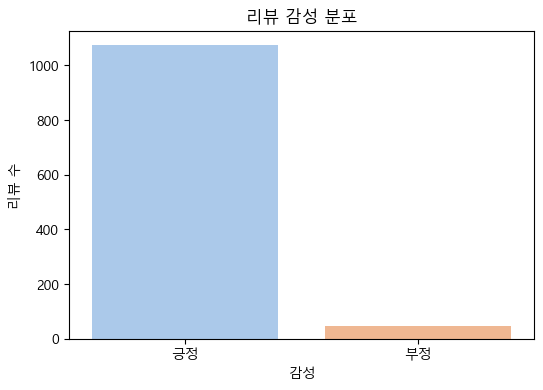

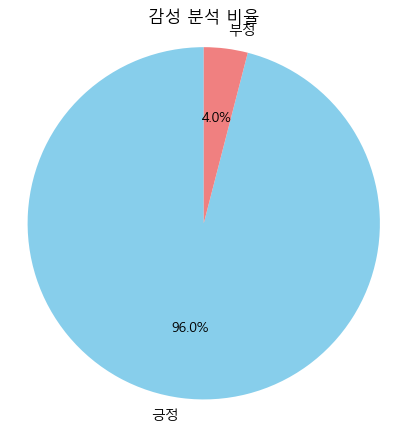

In [16]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# 결과 데이터 불러오기
df = pd.read_csv("naver_reviews_sentiment.csv")


# 감성 분포 계산
sentiment_counts = df['sentiment'].value_counts()


# 막대그래프
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='pastel')
plt.title("리뷰 감성 분포")
plt.xlabel("감성")
plt.ylabel("리뷰 수")
plt.show()


# 파이차트
plt.figure(figsize=(5, 5))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%.1f%%', startangle=90,
        colors=['skyblue', 'lightcoral'])
plt.title("감성 분석 비율")
plt.axis('equal')
plt.show()


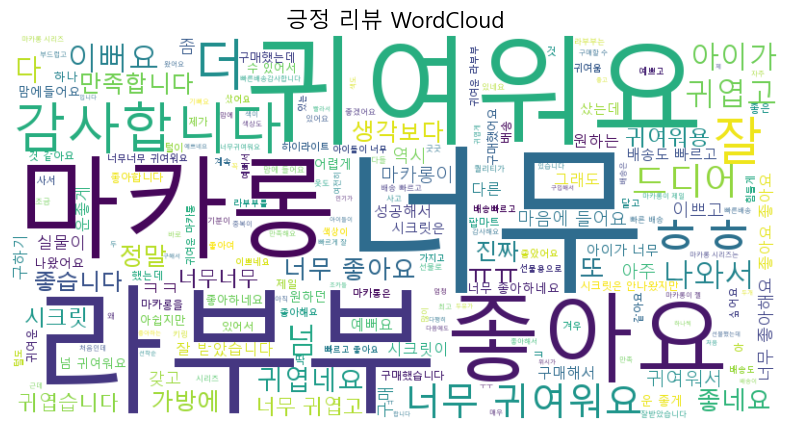

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd


# 데이터 불러오기
df = pd.read_csv("naver_reviews_sentiment.csv")


# Windows용 한글 폰트 경로 지정 (예: 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"


# 긍정 리뷰만 추출하여 하나의 문자열로 결합
positive_text = ' '.join(df[df['sentiment'] == '긍정']['review'])


# 워드클라우드 생성
wordcloud_pos = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=400
).generate(positive_text)


# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("긍정 리뷰 WordCloud", fontsize=16)
plt.show()


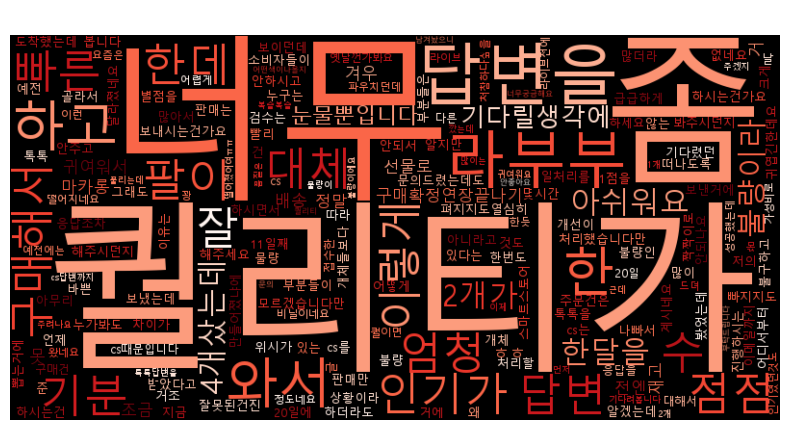

In [18]:
# 부정 리뷰 워드클라우드 생성
negative_text = ' '.join(df[df['sentiment'] == '부정']['review'])

wordcloud_neg = WordCloud(
    font_path=font_path,
    background_color='black',
    width=800,
    height=400,
    colormap='Reds'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("부정 리뷰 WordCloud", fontsize=16, color='white')
plt.show()


In [81]:
#pip install streamlit wordcloud matplotlib pandas

📌 변환된 날짜 예시:
0    2025-09-29
1    2025-09-29
2    2025-09-29
3    2025-09-29
4    2025-09-29
5    2025-09-29
6    2025-09-29
7    2025-09-29
8    2025-09-29
9    2025-09-29
10   2025-09-29
11   2025-09-29
12   2025-09-29
13   2025-09-29
14   2025-09-29
15   2025-09-29
16   2025-09-29
17   2025-09-29
18   2025-09-29
19   2025-09-29
Name: date, dtype: datetime64[ns]
📌 변환 실패 개수: 0


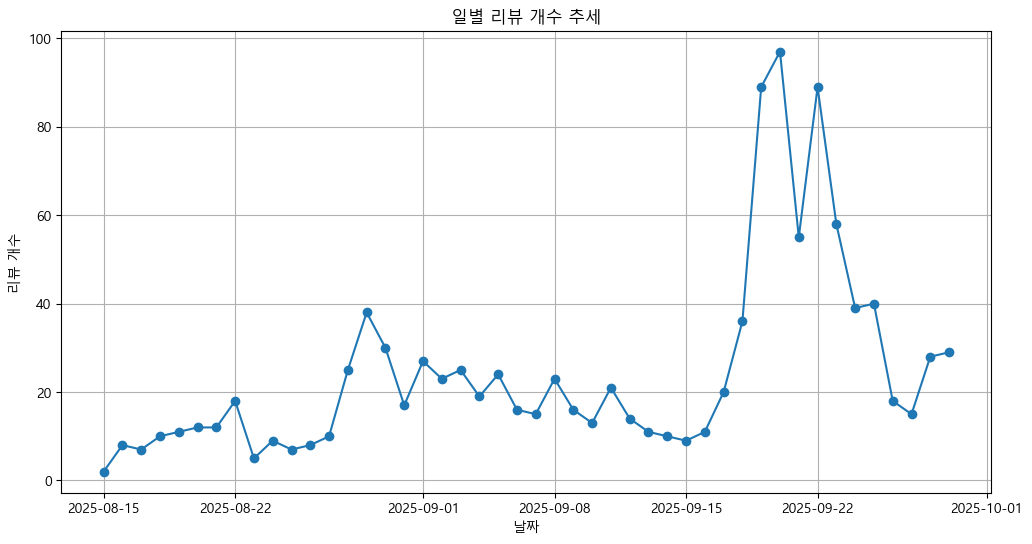

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 불러오기
df = pd.read_csv("naver_reviews_sentiment.csv")


# 날짜 컬럼 전처리
# 문자열 변환 + 공백 제거
df['date'] = df['date'].astype(str).str.strip()


# 날짜 변환 ("25.09.29." 같은 형식 처리)
df['date'] = pd.to_datetime(df['date'], format="%y.%m.%d.", errors='coerce')


# 변환 확인
print("변환된 날짜 예시:")
print(df['date'].head(20))
print("변환 실패 개수:", df['date'].isna().sum())


# 결측치 제거
df = df.dropna(subset=['date'])


# 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)


# 일별 리뷰 개수 집계
daily_counts = df.groupby(df['date']).size()


# 시각화
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts.values, marker='o')
plt.title("일별 리뷰 개수 추세")
plt.xlabel("날짜")
plt.ylabel("리뷰 개수")
plt.grid(True)
plt.show()

C:\Users\Hyeonseong\AppData\Local\Temp\ipykernel_39612\3182573669.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.groupby(pd.Grouper(key='date', freq='M')).size()
C:\Users\Hyeonseong\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


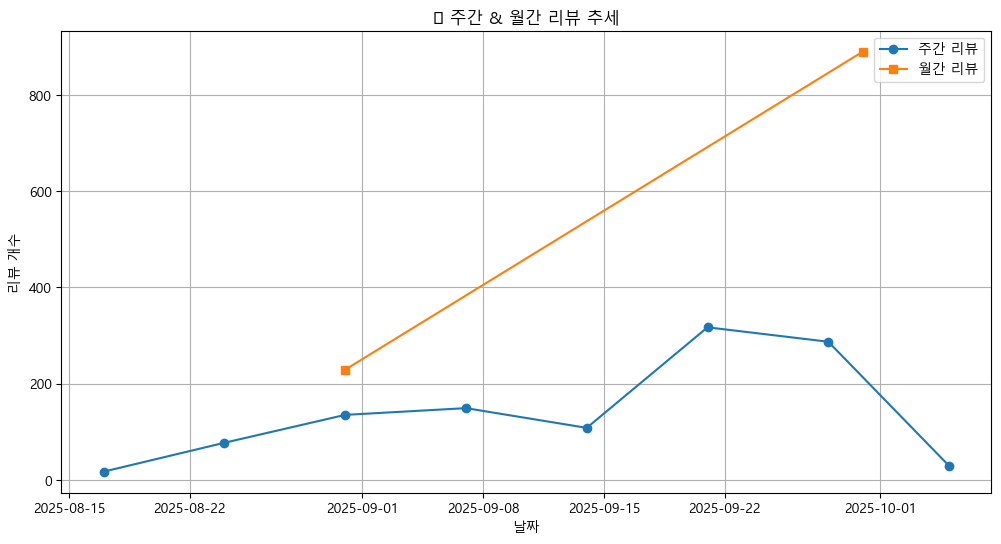

In [18]:
# 3. 주간 / 월간 리뷰 추세
weekly_counts = df.groupby(pd.Grouper(key='date', freq='W')).size()
monthly_counts = df.groupby(pd.Grouper(key='date', freq='M')).size()

plt.figure(figsize=(12,6))
plt.plot(weekly_counts.index, weekly_counts.values, marker='o', label="주간 리뷰")
plt.plot(monthly_counts.index, monthly_counts.values, marker='s', label="월간 리뷰")
plt.title("주간 & 월간 리뷰 추세")
plt.xlabel("날짜")
plt.ylabel("리뷰 개수")
plt.legend()
plt.grid(True)
plt.show()